In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q tf-keras-vis opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 5.2 MB/s eta 0:00:00


In [4]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [5]:
model_path = "/content/drive/MyDrive/Faceproject/models/liveness_model.h5"

model = load_model(model_path)

print("Model loaded successfully!")

Model loaded successfully!


In [7]:
import os

# Select one image directly from the Training dataset
sample_folder = "/content/drive/MyDrive/Faceproject/Dataset/Colab_Data/Training/real_part"

# Find the first color folder automatically
img_path = None

for root, dirs, files in os.walk(sample_folder):
    if os.path.basename(root).lower() == "color":
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                img_path = os.path.join(root, file)
                break
    if img_path is not None:
        break

print("Selected Image:")
print(img_path)

Selected Image:
/content/drive/MyDrive/Faceproject/Dataset/Colab_Data/Training/real_part/CLKJ_CS0110/real.rssdk/color/441.jpg


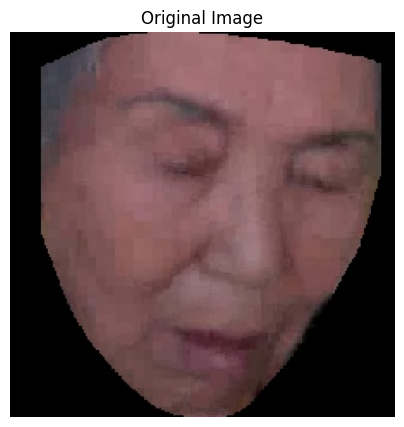

In [8]:
img = image.load_img(img_path, target_size=(224,224))

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [9]:
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

print("Input Shape:", img_array.shape)

Input Shape: (1, 224, 224, 3)


In [10]:
prediction = model.predict(img_array)[0][0]

if prediction > 0.5:
    print("Prediction: REAL FACE")
    print("Confidence:", round(prediction*100,2), "%")
else:
    print("Prediction: FAKE FACE")
    print("Confidence:", round((1-prediction)*100,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Prediction: REAL FACE
Confidence: 75.87 %


In [11]:
for layer in reversed(model.layers):
    if len(layer.output.shape) == 4:
        last_conv_layer_name = layer.name
        break

print("Last Conv Layer:", last_conv_layer_name)

Last Conv Layer: out_relu


In [12]:
grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer_name).output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0)
heatmap = heatmap / np.max(heatmap)

print("Heatmap generated successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Heatmap generated successfully!


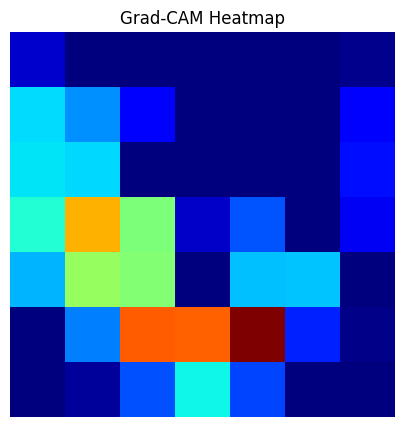

In [13]:
plt.figure(figsize=(5,5))
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

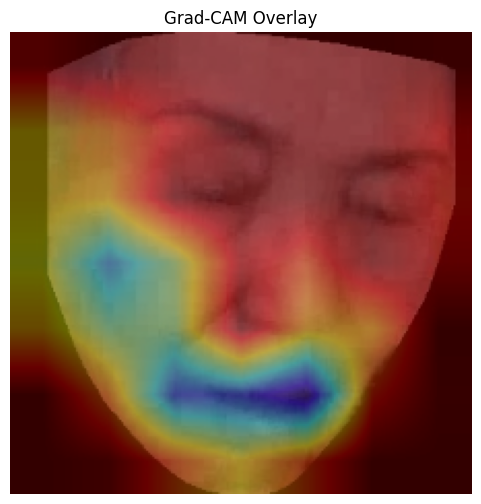

In [15]:
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
original_img = cv2.resize(original_img, (224,224))

heatmap_resized = cv2.resize(heatmap, (224,224))
heatmap_resized = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(
    heatmap_resized,
    cv2.COLORMAP_JET
)

superimposed_img = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(6,6))
plt.imshow(superimposed_img)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()

In [16]:
output_dir = "/content/drive/MyDrive/Faceproject/outputs"
os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "gradcam_output.png")

cv2.imwrite(
    save_path,
    cv2.cvtColor(superimposed_img, cv2.COLOR_RGB2BGR)
)

print("Grad-CAM image saved successfully!")
print("Saved at:", save_path)

Grad-CAM image saved successfully!
Saved at: /content/drive/MyDrive/Faceproject/outputs/gradcam_output.png
